# 이동 카메라 기반 객체 계수 파이프라인 — 검출 · 중복 제거 · RGB-D 실측 · 엣지 최적화

카메라가 움직이면서 촬영한 영상에서 대상 객체의 **개수와 실제 크기(mm)** 를 뽑아내는
파이프라인을 Jetson 위에서 직접 구성합니다.

이 노트북은 [vision_compression_practice](vision_compression_practice.ipynb)(ResNet-18 → TensorRT INT8, 10.4배)의
후속입니다. 거기서 만든 엣지 최적화 파이프라인을 실제 태스크(검출 · 추적)에 적용합니다.

> 코드 셀 첫 줄에 `[코드 N]`으로 번호를 달아두었습니다 (전체 6개).

### 왜 이 4단계인가

| 단계 | 문제 | 선택한 아키텍처 | 코드셀 |
|---|---|---|---|
| 1. 검출 | 한 프레임 안의 객체를 찾는다 | **YOLO11** | 2 |
| 1-b. 도메인 갭 | 사전학습 모델은 현장이 바뀌면 무너진다 | (동일 가중치 비교) | 3 |
| 2. **중복 제거** | 카메라가 이동하니 같은 객체가 여러 프레임에 나온다 | **ByteTrack** | 4 |
| 3. 실측 | 픽셀 크기는 거리에 따라 변한다 → mm로 못 바꾼다 | **RGB-D depth 역투영** | 5 |
| 4. 배포 | 엣지 GPU는 비싸다. 모델이 가벼워야 한다 | **TensorRT FP16** | 6 |

> 2단계가 이 노트북의 핵심입니다. 단일 이미지 계수는 정확도만 맞추면 되지만,
> 이동 플랫폼에서는 **프레임마다 세면 같은 객체를 수십 번 셉니다.** 추적으로 개체 ID를 유지하고
> 고유 ID 수를 세야 실제 개수가 나옵니다. 현장 시스템과 데모의 결정적 차이가 여기서 갈립니다.

## 전체 흐름 한눈에 보기

```mermaid
flowchart TD
    A["YOLO11n<br/>COCO 사전학습"] --> B["가판대 이미지 검출<br/>라벨 27개 중 10개 검출"]

    B --> C{"동일 가중치를<br/>다른 현장 이미지에"}
    C --> D["도메인 갭 실험<br/>검출 7개, 전부 오분류<br/>(해당 클래스가 COCO에 없음)"]

    B --> E["이동 촬영 시뮬레이션<br/>12프레임"]
    E --> F["프레임별 합산: 75개<br/>ByteTrack 고유 ID: 8개"]
    F --> G["9.4배 과대계수<br/>(중복 제거의 필요성)"]

    B --> H["RGB-D depth 역투영"]
    H --> I["같은 60px 박스<br/>400mm→39mm, 1200mm→117mm<br/>(3배 차이)"]

    B --> J["ONNX → TensorRT FP16"]
    J --> K["30 FPS → 135 FPS<br/>(4.4배)"]

    D -.->|"검출이 무너지면<br/>추적도 같이 무너짐"| G

    style D fill:#f8d7da,stroke:#721c24
    style G fill:#fff3cd,stroke:#856404
    style I fill:#d1ecf1,stroke:#0c5460
    style K fill:#d4edda,stroke:#155724
```

## 0단계. 환경 준비

이 Jetson의 `torch 2.13.0+cu130`은 CUDA 지원 특수 빌드입니다.
`pip install ultralytics`를 그냥 실행하면 의존성 해결 과정에서 이 torch를 **일반 빌드로 덮어써
CUDA가 통째로 깨집니다.** (vision_compression 노트북에서 torchvision에 `--no-deps`를 쓴 것과 같은 이유)

그래서 다음 셀에서는:

1. `ultralytics`와 `ultralytics-thop`을 `--no-deps`로 설치한다 (둘 다 torch를 의존성으로 걸고 있음)
2. torch와 무관한 순수 패키지(psutil, py-cpuinfo, opencv 등)만 정상 설치한다
3. 설치 전후로 `torch.__version__`과 `cuda.is_available()`을 비교해 훼손 여부를 즉시 확인한다
   — 어긋나면 `assert`로 그 자리에서 멈춘다

In [1]:
# [코드 1] 환경 준비 — torch 보호 설치
import subprocess, sys, importlib.util, os
from importlib.metadata import version, PackageNotFoundError

import torch

def disk_version(pkg):
    """디스크에 설치된 버전(패키지 메타데이터)을 읽는다.
    이미 로드된 torch를 importlib.reload 하면 TORCH_LIBRARY('triton')가
    두 번 등록되며 RuntimeError가 나므로, reload 대신 메타데이터로 확인한다."""
    try:
        return version(pkg)
    except PackageNotFoundError:
        return None

BEFORE = (disk_version("torch"), disk_version("torchvision"))
print("설치 전 torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("설치 전 디스크 버전:", BEFORE)

def pip(args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + args, check=True)

def ensure(mod, pkg=None, no_deps=False):
    if importlib.util.find_spec(mod) is None:
        print("installing", pkg or mod, "(no_deps)" if no_deps else "")
        pip((["--no-deps"] if no_deps else []) + [pkg or mod])
    else:
        print(mod, "OK")

# torch를 의존성으로 거는 것들 -> 반드시 --no-deps
ensure("ultralytics", no_deps=True)
ensure("thop", "ultralytics-thop", no_deps=True)

# torch와 무관한 순수 의존성만 정상 설치
for mod, pkg in [("cv2", "opencv-python-headless"), ("psutil", "psutil"),
                 ("cpuinfo", "py-cpuinfo"), ("yaml", "PyYAML"),
                 ("matplotlib", "matplotlib"), ("scipy", "scipy"), ("pandas", "pandas")]:
    ensure(mod, pkg)

AFTER = (disk_version("torch"), disk_version("torchvision"))
print()
print("설치 후 디스크 버전:", AFTER)
assert AFTER == BEFORE, f"torch/torchvision이 교체됨! {BEFORE} -> {AFTER} (CUDA 빌드 복구 필요)"
print("torch 무사 — CUDA:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "-")

WORK = os.path.expanduser("~/counting_lab")
os.makedirs(WORK, exist_ok=True)
print("작업 디렉토리:", WORK)

설치 전 torch: 2.13.0+cu130 | CUDA: True
설치 전 디스크 버전: ('2.13.0', '0.28.0')
ultralytics OK
thop OK
cv2 OK
psutil OK
cpuinfo OK
yaml OK
matplotlib OK
scipy OK
pandas OK

설치 후 디스크 버전: ('2.13.0', '0.28.0')
torch 무사 — CUDA: Orin
작업 디렉토리: /home/manager/counting_lab


/home/manager/mlops-lab-env/lib/python3.12/site-packages/torch/cuda/__init__.py:422: UserWarning: Found GPU0 Orin which is of compute capability (CC) 8.7.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 11.0 which supports hardware CC >=11.0,<12.0
- 12.0 which supports hardware CC >=12.0,<13.0
No published PyTorch CUDA builds for release 2.13.0+cu130 support this GPU. Visit https://pytorch.org/get-started/locally/ to find a compatible release.
  _warn_unsupported_code(d, device_cc, code_ccs)


## 1단계. 검출 기반 계수

**YOLO11**을 씁니다. 검출 계열을 고르는 이유:

- **속도** — 엣지 GPU에서 실시간이 나와야 이동 플랫폼에 올릴 수 있습니다(`YOLO11n`은 2.6M 파라미터).
- **바운딩박스가 곧 계측 단위** — 객체 하나 = 박스 하나라 계수·크기 계측에 바로 연결됩니다.
- 면적·부피까지 필요하면 `yolo11n-seg`(인스턴스 분할)로 바꾸면 마스크를 얻습니다.

> **밀집·겹침이 심하면 검출은 한계가 있습니다.** 그때는
> density map 회귀(CSRNet) 또는 point-based(P2PNet)로 갈아타는 게 정석입니다.
> "박스를 그릴 수 있을 만큼 분리되는가"가 갈림길입니다.

다음 셀은 COCO 사전학습 가중치로 파이프라인 골격을 먼저 세웁니다.
실제 과제에서는 이 자리에 **대상 도메인 데이터로 파인튜닝한 가중치**가 들어갑니다.

검출 결과: {'banana': 5, 'apple': 3, 'orange': 2}
계측 대상 클래스: ['apple', 'banana', 'orange']
[1단계] 단일 프레임 개수 = 10


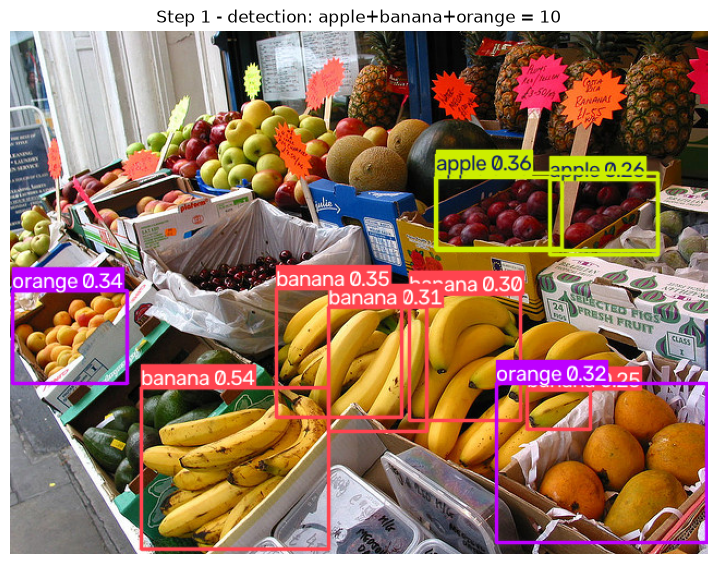

In [2]:
# [코드 2] 1단계 — 단일 프레임 검출 및 계수
import os, urllib.request, collections
import cv2, matplotlib.pyplot as plt
from ultralytics import YOLO

def show(img_bgr, title="", figsize=(9, 7)):
    """OpenCV BGR 배열을 노트북에 표시 (이후 셀에서도 재사용)"""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

model = YOLO("yolo11n.pt")            # 최초 1회 자동 다운로드 (~5MB)

# COCO val2017에서 대상이 좌우로 넓게 퍼진 이미지를 고름 (이동 촬영 재현에 유리)
#   560256: 과일 가판대 — apple 12 / orange 9 / banana 6 (라벨 기준 27개)
#   303566: apple 13 / orange 13
CANDIDATES = [
    "http://images.cocodataset.org/val2017/000000560256.jpg",
    "http://images.cocodataset.org/val2017/000000303566.jpg",
    "https://ultralytics.com/images/bus.jpg",          # 최후 폴백
]
img_path = os.path.join(WORK, "sample_fruit.jpg")
if not os.path.exists(img_path):
    for url in CANDIDATES:
        try:
            urllib.request.urlretrieve(url, img_path)
            print("샘플 이미지:", url)
            break
        except Exception as e:
            print("실패:", url, e)

r = model(img_path, verbose=False)[0]
counts = collections.Counter(r.names[int(c)] for c in r.boxes.cls)
print("검출 결과:", dict(counts))

# COCO의 과일 클래스가 잡히면 그것들을, 없으면 가장 많이 잡힌 클래스를 대상으로
FRUIT = {"apple", "orange", "banana"}
hit = FRUIT & set(counts)
TARGET = sorted(hit) if hit else ([counts.most_common(1)[0][0]] if counts else [])
n = sum(v for k, v in counts.items() if k in TARGET)
print("계측 대상 클래스:", TARGET)
print(f"[1단계] 단일 프레임 개수 = {n}")

show(r.plot(), f"Step 1 - detection: {'+'.join(TARGET)} = {n}")

## 도메인 갭

앞 셀의 이미지는 가판대에 정돈된 대상이었습니다. COCO 사전학습 모델이 잘 맞는 조건입니다.
실제 현장은 다릅니다:

- 대상이 잎에 가려지고(폐색), 서로 겹쳐 있고, 배경과 색이 비슷합니다
- 성숙 단계에 따라 색이 완전히 달라집니다 (초록 → 주황 → 빨강)
- **그리고 결정적으로, COCO 80개 클래스에는 이 대상이 아예 없습니다**

다음 셀은 완전히 동일한 가중치·동일한 코드를 실제 현장 이미지에 그대로 적용합니다.

> 예상 결과: 검출 0개, 또는 일부를 엉뚱한 클래스(apple/orange 등)로 오인.
> 클래스가 학습된 적 없으니 당연한 결과이고, 바로 그 점이 핵심입니다.

왜 사전학습 모델을 그대로 배포할 수 없는지, 그리고 왜 파인튜닝과 라벨링 전략
(SAM2 자동 라벨링 등)이 파이프라인의 전제인지에 대한 가장 직접적인 근거입니다.
성능 튜닝 이전에 **클래스 정의부터 다시 해야 하는** 문제입니다.

> 이미지 출처: Laboro Tomato 데이터셋(CC BY-NC-SA 4.0)의 공개 예시 이미지를 실행 시점에
> 내려받아 사용합니다. 저장소에 이미지를 포함하지 않습니다.

이미지 크기: 949 x 1231

검출 결과: {'apple': 6, 'orange': 1}
과일 클래스(apple, banana, orange) 검출 수: 7

                     가판대        현장
과일 검출 수               10         7

주의 — 숫자만 보면 안 됩니다.
이 이미지에는 사과도 오렌지도 없습니다. 검출된 7개는 전부 오분류입니다.
COCO 80개 클래스에 이 대상 자체가 없으니, 모델은 가장 비슷해 보이는 클래스로 밀어냅니다.
게다가 육안으로 세면 이 한 장에만 대상이 훨씬 많습니다 — 대부분은 놓쳤습니다.

정리: 검출률이 낮은 게 아니라 '무엇을 찾을지'가 정의되지 않은 상태입니다.
성능을 튜닝할 문제가 아니라 클래스 정의부터 다시 해야 하는 문제이고,
그래서 도메인 데이터 파인튜닝과 라벨링 전략이 성능 논의보다 앞섭니다.


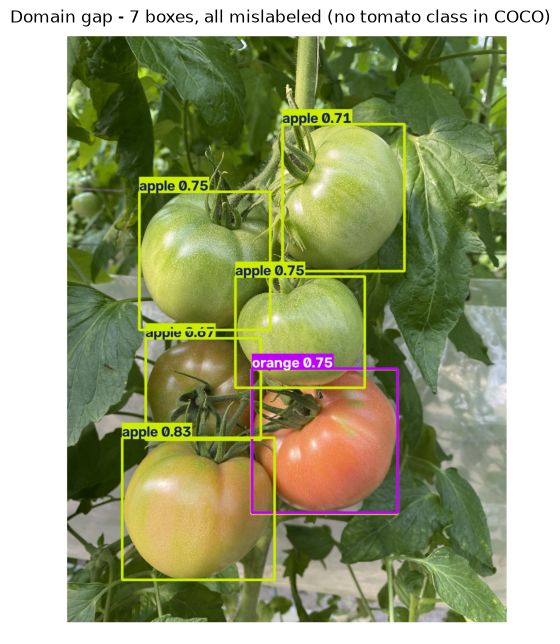

In [3]:
# [코드 3] 도메인 갭 — 동일 가중치를 실제 현장 이미지에 적용
import os, urllib.request, collections
import cv2

# Laboro Tomato (CC BY-NC-SA 4.0) 공개 예시 — 시설재배 현장 촬영
FIELD_URLS = [
    "https://raw.githubusercontent.com/laboroai/LaboroTomato/master/examples/raw_IMG_1066.png",
    "https://raw.githubusercontent.com/laboroai/LaboroTomato/master/examples/raw_IMG_1246.png",
]
field_path = os.path.join(WORK, "field.png")
if not os.path.exists(field_path):
    for url in FIELD_URLS:
        try:
            urllib.request.urlretrieve(url, field_path)
            print("현장 이미지:", url.rsplit("/", 1)[-1])
            break
        except Exception as e:
            print("실패:", url, e)

field = cv2.imread(field_path)
print("이미지 크기:", field.shape[1], "x", field.shape[0])

rf = model(field, verbose=False)[0]
cf = collections.Counter(rf.names[int(c)] for c in rf.boxes.cls)
n_field = sum(v for k, v in cf.items() if k in FRUIT)

print("\n검출 결과:", dict(cf) if cf else "(아무것도 검출되지 않음)")
print(f"과일 클래스({', '.join(sorted(FRUIT))}) 검출 수: {n_field}")

print(f"\n{'':16}{'가판대':>8}{'현장':>10}")
print(f"{'과일 검출 수':16}{n:>8}{n_field:>10}")

print("\n주의 — 숫자만 보면 안 됩니다.")
if n_field:
    print(f"이 이미지에는 사과도 오렌지도 없습니다. 검출된 {n_field}개는 전부 오분류입니다.")
    print("COCO 80개 클래스에 이 대상 자체가 없으니, 모델은 가장 비슷해 보이는 클래스로 밀어냅니다.")
else:
    print("아예 아무것도 잡지 못했습니다.")
print("게다가 육안으로 세면 이 한 장에만 대상이 훨씬 많습니다 — 대부분은 놓쳤습니다.")
print("\n정리: 검출률이 낮은 게 아니라 '무엇을 찾을지'가 정의되지 않은 상태입니다.")
print("성능을 튜닝할 문제가 아니라 클래스 정의부터 다시 해야 하는 문제이고,")
print("그래서 도메인 데이터 파인튜닝과 라벨링 전략이 성능 논의보다 앞섭니다.")

show(rf.plot(), f"Domain gap - {len(rf.boxes)} boxes, all mislabeled (no tomato class in COCO)", figsize=(6, 8))

## 2단계. 이동 중 중복 제거

카메라가 이동하면 같은 객체가 연속된 여러 프레임에 등장합니다.
프레임마다 세어 더하면 개수가 몇 배로 부풀려집니다.

해결: ByteTrack으로 프레임 간 개체 ID를 유지하고, 고유 ID의 개수를 셉니다.

```
프레임별 검출  →  ByteTrack(ID 부여)  →  set(ID) 크기 = 실제 개수
```

ByteTrack을 고른 이유는 낮은 신뢰도 검출까지 버리지 않고 추적에 활용하기 때문입니다.
부분 폐색(occlusion)이 발생하면 검출 점수가 떨어지는데, 점수가 낮다고 버리면 ID가 끊깁니다.
**끊긴 ID는 같은 객체를 새 개체로 다시 셉니다.**

다음 셀은 이미지 한 장 위를 가로로 훑는 창(sliding window)으로 프레임 시퀀스를 만들어
"카메라가 옆으로 지나가며 촬영하는 상황"을 재현합니다. 카메라가 없어도 중복 문제를 그대로 볼 수 있습니다.

[가판대] 640x480, 12프레임, 이동 가로(좌->우)

(A) 프레임별 합산   :  75 개   <- 같은 개체를 반복해서 셈
(B) 고유 ID 기준    :   8 개   <- ByteTrack으로 중복 제거

순진한 방법은 실제의 9.4배로 과대계수합니다.
이동 촬영에서 추적이 선택이 아니라 필수인 이유입니다.
전체 고유 ID: [1, 2, 3, 4, 5, 6, 7, 16]


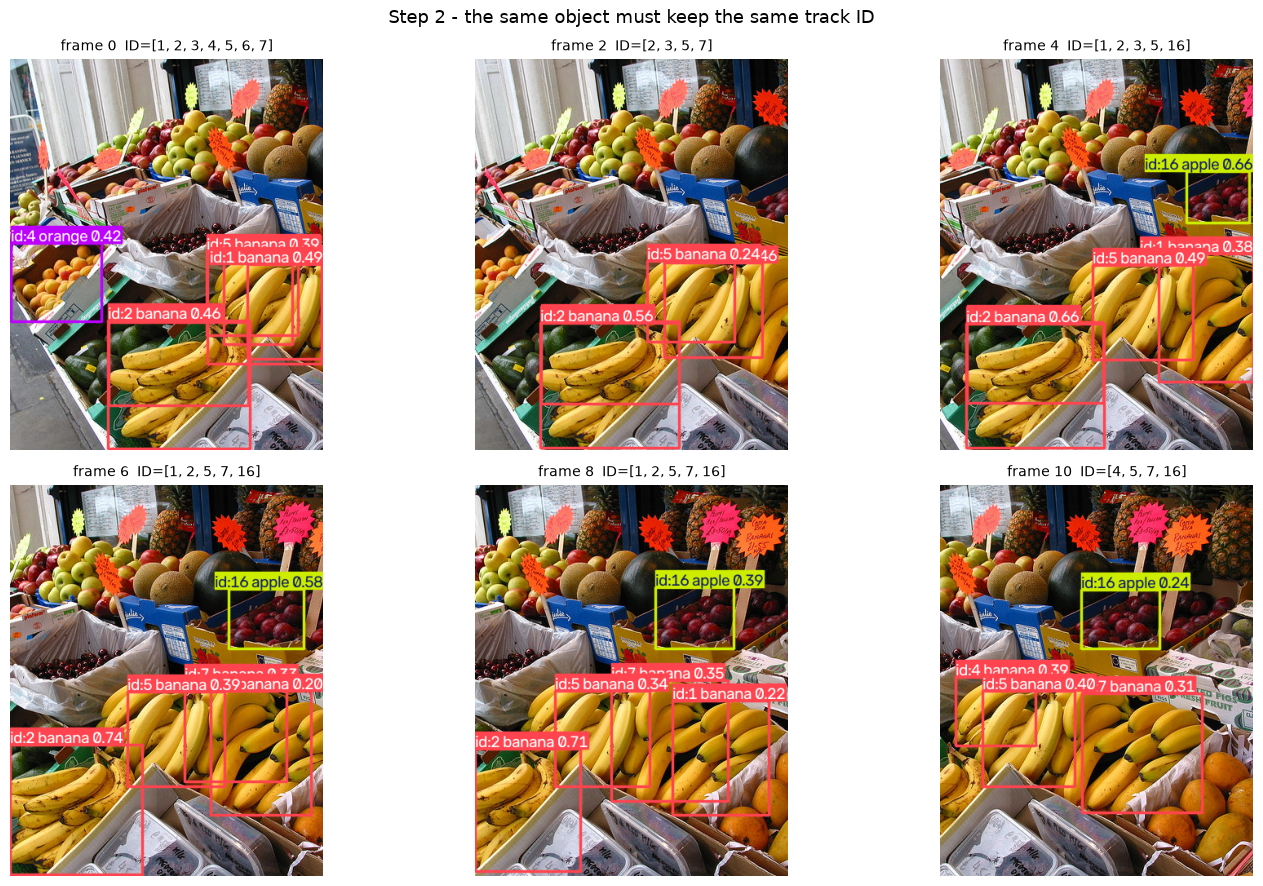

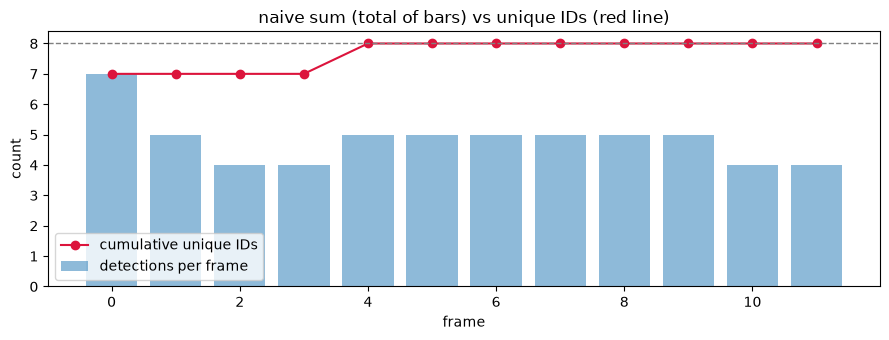


[현장] 949x1231, 12프레임, 이동 세로(위->아래)

                     가판대        현장
프레임별 합산               75        77
고유 ID                  8         9
과대계수 배율             9.4x      8.6x

현장 쪽 숫자는 '잘 세었다'는 뜻이 아닙니다 —
[코드 3]에서 확인했듯 그 검출들은 애초에 틀린 클래스입니다.
추적은 검출 위에 얹히는 층이라, 검출이 무너지면 추적도 같이 무너집니다.
=> 추적 알고리즘을 바꿔서 해결할 문제가 아닙니다. 파인튜닝이 먼저입니다.


In [4]:
# [코드 4] 2단계 — 이동 촬영 시뮬레이션 + ByteTrack 중복 제거
import cv2, os
import matplotlib.pyplot as plt

def make_frames(img, n_frames=12, ratio=0.6):
    """원본 위를 훑어 이동 촬영을 재현. 세로로 긴 이미지는 위->아래로 훑는다
    (온실에서 카메라가 작물 높이를 따라 움직이는 상황에 가깝다)."""
    H, W = img.shape[:2]
    vertical = H > W
    frames = []
    for i in range(n_frames):
        t = i / (n_frames - 1)
        if vertical:
            h = int(H * ratio); y = int((H - h) * t)
            frames.append(img[y:y + h, :].copy())
        else:
            w = int(W * ratio); x = int((W - w) * t)
            frames.append(img[:, x:x + w].copy())
    return frames, ("세로(위->아래)" if vertical else "가로(좌->우)")

def track_count(img, target, n_frames=12, label=""):
    """(A) 프레임별 합산 vs (B) ByteTrack 고유 ID 수를 함께 구한다."""
    frames, direction = make_frames(img, n_frames)
    print(f"[{label}] {img.shape[1]}x{img.shape[0]}, {n_frames}프레임, 이동 {direction}")

    naive = 0
    for f in frames:
        rr = model(f, verbose=False)[0]
        naive += sum(1 for c in rr.boxes.cls if rr.names[int(c)] in target)

    mt = YOLO("yolo11n.pt")            # 추적 상태를 초기화하려면 새 인스턴스가 필요
    seen, annotated, per_frame = set(), [], []
    for f in frames:
        rr = mt.track(f, persist=True, tracker="bytetrack.yaml", verbose=False)[0]
        ids = []
        if rr.boxes.id is not None:
            for tid, c in zip(rr.boxes.id.tolist(), rr.boxes.cls.tolist()):
                if rr.names[int(c)] in target:
                    seen.add(int(tid)); ids.append(int(tid))
        annotated.append(rr.plot()); per_frame.append(sorted(ids))
    return dict(naive=naive, uniq=len(seen), ids=sorted(seen),
                annotated=annotated, per_frame=per_frame, n=n_frames)

# ---------- (1) 검출이 동작하는 이미지: 메커니즘 증명 ----------
stall = track_count(cv2.imread(img_path), TARGET, label="가판대")
print(f"\n(A) 프레임별 합산   : {stall['naive']:>3} 개   <- 같은 개체를 반복해서 셈")
print(f"(B) 고유 ID 기준    : {stall['uniq']:>3} 개   <- ByteTrack으로 중복 제거")
if stall["uniq"]:
    print(f"\n순진한 방법은 실제의 {stall['naive'] / stall['uniq']:.1f}배로 과대계수합니다.")
    print("이동 촬영에서 추적이 선택이 아니라 필수인 이유입니다.")
    print("전체 고유 ID:", stall["ids"])

pick = list(range(0, stall["n"], max(1, stall["n"] // 6)))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, i in zip(axes.ravel(), pick):
    ax.imshow(cv2.cvtColor(stall["annotated"][i], cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {i}  ID={stall['per_frame'][i]}", fontsize=10); ax.axis("off")
fig.suptitle("Step 2 - the same object must keep the same track ID", fontsize=13)
plt.tight_layout(); plt.show()

cum, acc = [], set()
for ids in stall["per_frame"]:
    acc |= set(ids); cum.append(len(acc))
plt.figure(figsize=(9, 3.5))
plt.bar(range(stall["n"]), [len(x) for x in stall["per_frame"]], alpha=.5, label="detections per frame")
plt.plot(range(stall["n"]), cum, "o-", color="crimson", label="cumulative unique IDs")
plt.axhline(stall["uniq"], ls="--", c="gray", lw=1)
plt.xlabel("frame"); plt.ylabel("count"); plt.legend()
plt.title("naive sum (total of bars) vs unique IDs (red line)")
plt.tight_layout(); plt.show()

# ---------- (2) 검출이 무너진 이미지: 추적도 함께 무너진다 ----------
print("\n" + "=" * 62)
field_t = track_count(cv2.imread(field_path), FRUIT, label="현장")

def ratio(d):
    return d["naive"] / d["uniq"] if d["uniq"] else float("nan")

print(f"\n{'':14}{'가판대':>10}{'현장':>10}")
print(f"{'프레임별 합산':14}{stall['naive']:>10}{field_t['naive']:>10}")
print(f"{'고유 ID':14}{stall['uniq']:>10}{field_t['uniq']:>10}")
print(f"{'과대계수 배율':14}{ratio(stall):>9.1f}x{ratio(field_t):>9.1f}x")

print("\n현장 쪽 숫자는 '잘 세었다'는 뜻이 아닙니다 —")
print("[코드 3]에서 확인했듯 그 검출들은 애초에 틀린 클래스입니다.")
print("추적은 검출 위에 얹히는 층이라, 검출이 무너지면 추적도 같이 무너집니다.")
print("=> 추적 알고리즘을 바꿔서 해결할 문제가 아닙니다. 파인튜닝이 먼저입니다.")

## 3단계. RGB-D 실측

**RGB만으로는 크기를 잴 수 없습니다.** 같은 객체도 카메라에 가까우면 크게, 멀면 작게 찍힙니다.

"박스가 120픽셀"은 거리를 모르면 아무 의미가 없습니다.

깊이(depth)가 있으면 핀홀 카메라 모델로 픽셀 → 실제 좌표(mm)를 역투영할 수 있습니다:

$$X = \frac{(u - c_x)\, Z}{f_x}, \qquad Y = \frac{(v - c_y)\, Z}{f_y}$$

- $(u, v)$: 픽셀 좌표, $Z$: 그 픽셀의 깊이(mm)
- $(f_x, f_y)$: 초점거리(픽셀 단위), $(c_x, c_y)$: 주점 — 카메라 내부파라미터

RealSense D435 같은 RGB-D 카메라는 `rs.intrinsics`로 이 값을 직접 주고,
depth를 컬러 프레임에 정렬(align)해주므로 같은 (u, v)로 두 값을 함께 읽을 수 있습니다.

이 계산이 생기면 따라오는 것들:

- 객체의 **실제 치수·부피** 산출
- 관심 지점의 **3D 좌표** → 시간에 따른 위치 변화 추적
- **거리 기반 필터링** → 배경의 먼 객체를 계측에서 제외 (2단계 중복 제거와 함께 쓰면 강력)

다음 셀은 카메라 없이도 검증할 수 있도록 합성 depth(기울어진 평면)로 계산 경로를 확인합니다.

동일한 60x60 픽셀 박스의 실제 크기:
   거리   400 mm  ->   39.0 x  39.0 mm
   거리   800 mm  ->   78.0 x  78.0 mm
   거리  1200 mm  ->  117.1 x 117.1 mm

같은 픽셀 크기가 거리에 따라 3배까지 달라집니다. RGB만으로 계측이 불가능한 이유입니다.

검출된 개체의 실측 추정 (합성 depth 기준):
   banana     z=   934mm  크기   260x  224mm  3D=(  -173,   245,   934)
   apple      z=   738mm  크기   244x   86mm  3D=(   206,   -90,   738)
   banana     z=   846mm  크기   158x  162mm  3D=(   -26,    76,   846)
   orange     z=   833mm  크기   142x  115mm  3D=(  -360,    54,   833)
   orange     z=   930mm  크기   292x  221mm  3D=(   337,   236,   930)


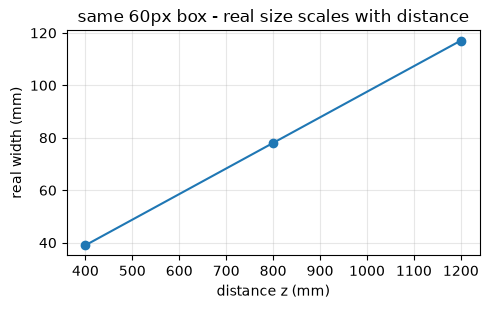

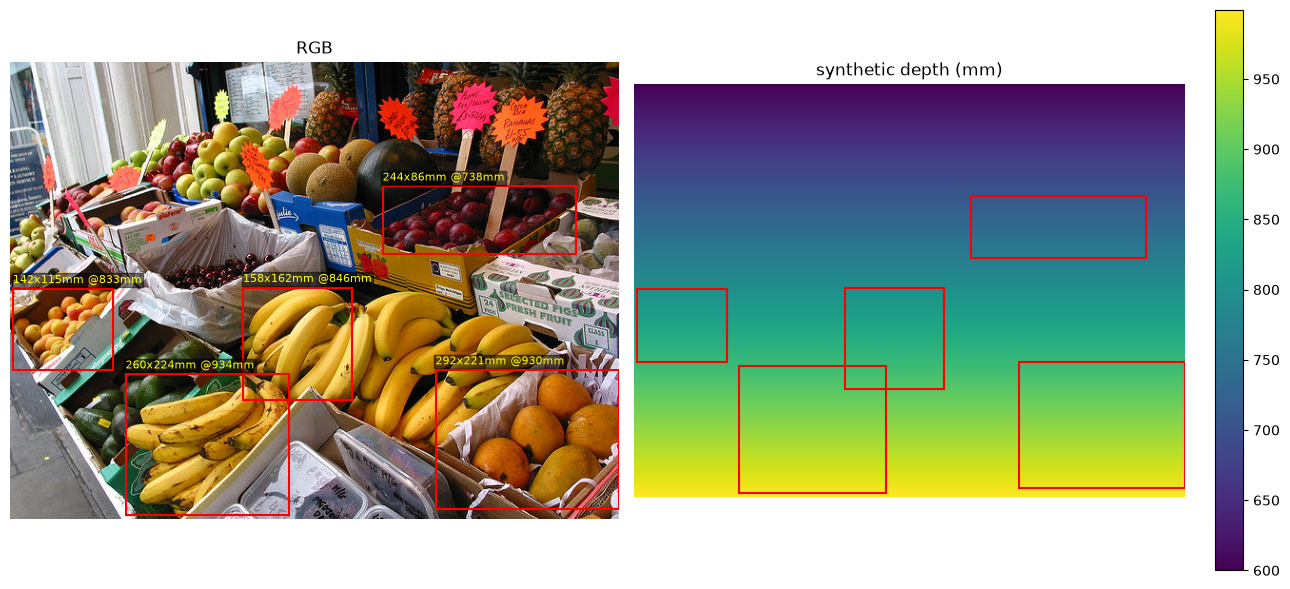

In [5]:
# [코드 5] 3단계 — depth 역투영으로 실측 크기 구하기
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# RealSense D435 컬러 스트림 640x480의 대표적인 내부파라미터 (실제 값은 카메라에서 읽어야 함)
FX, FY, CX, CY = 615.0, 615.0, 320.0, 240.0

def backproject(u, v, z_mm):
    """픽셀 (u,v) + 깊이 z(mm) -> 카메라 좌표계 3D 점 (mm)"""
    x = (u - CX) * z_mm / FX
    y = (v - CY) * z_mm / FY
    return np.array([x, y, z_mm])

def bbox_size_mm(box, depth_mm):
    """바운딩박스의 실제 가로/세로 길이(mm). box=(x1,y1,x2,y2)"""
    x1, y1, x2, y2 = box
    p1, p2 = backproject(x1, y1, depth_mm), backproject(x2, y2, depth_mm)
    return abs(p2[0] - p1[0]), abs(p2[1] - p1[1])

# 검증: 같은 픽셀 크기라도 거리가 다르면 실측이 달라진다
box = (300, 220, 360, 280)          # 60x60 픽셀
print("동일한 60x60 픽셀 박스의 실제 크기:")
sizes = []
for z in (400, 800, 1200):
    w, h = bbox_size_mm(box, z)
    sizes.append((z, w))
    print(f"   거리 {z:>5} mm  ->  {w:5.1f} x {h:5.1f} mm")
print("\n같은 픽셀 크기가 거리에 따라 3배까지 달라집니다. RGB만으로 계측이 불가능한 이유입니다.")

# 실제 검출 결과에 합성 depth를 적용
rr = model(img_path, verbose=False)[0]
H_img, W_img = rr.orig_shape
vv = np.arange(H_img)[:, None]
depth = (600 + 400 * vv / H_img + np.zeros((1, W_img))).astype(np.float32)  # 아래로 갈수록 멀어짐

rows = []
print("\n검출된 개체의 실측 추정 (합성 depth 기준):")
for b, c in list(zip(rr.boxes.xyxy.tolist(), rr.boxes.cls.tolist()))[:5]:
    x1, y1, x2, y2 = b
    cu, cv_ = int((x1 + x2) / 2), int((y1 + y2) / 2)
    z = float(depth[min(cv_, H_img - 1), min(cu, W_img - 1)])
    w_mm, h_mm = bbox_size_mm(b, z)
    rows.append((b, rr.names[int(c)], z, w_mm, h_mm))
    P = backproject(cu, cv_, z)
    print(f"   {rr.names[int(c)]:<10} z={z:6.0f}mm  크기 {w_mm:5.0f}x{h_mm:5.0f}mm  "
          f"3D=({P[0]:6.0f},{P[1]:6.0f},{P[2]:6.0f})")

# --- 시각화 1: 거리에 따라 실측이 어떻게 달라지는가 ---
plt.figure(figsize=(5, 3.2))
plt.plot([s[0] for s in sizes], [s[1] for s in sizes], "o-")
plt.xlabel("distance z (mm)"); plt.ylabel("real width (mm)")
plt.title("same 60px box - real size scales with distance")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# --- 시각화 2: depth 맵 + 박스별 실측 라벨 ---
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)); ax[0].set_title("RGB")
im = ax[1].imshow(depth, cmap="viridis"); ax[1].set_title("synthetic depth (mm)")
plt.colorbar(im, ax=ax[1], fraction=.046)
for (x1, y1, x2, y2), name, z, w_mm, h_mm in rows:
    for a in ax:
        a.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                      fill=False, ec="red", lw=1.5))
    ax[0].text(x1, y1 - 6, f"{w_mm:.0f}x{h_mm:.0f}mm @{z:.0f}mm",
               color="yellow", fontsize=8,
               bbox=dict(fc="black", alpha=.5, pad=1))
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4단계. 엣지 배포

엣지 연산은 원가 항목입니다. GPU가 상위 사양에만 들어가는 제품 구성이라면
**모델이 무거우면 탑재 자체가 안 됩니다.** 아키텍처 선택이 곧 탑재 가능성입니다.

[vision_compression_practice](vision_compression_practice.ipynb)에서 ResNet-18로 확인한 결론을 그대로 적용합니다:

| | 그때(ResNet-18, batch 16) | 여기(YOLO11n, 640x640) |
|---|---|---|
| PyTorch eager | 56.0 ms | 다음 셀에서 측정 |
| TensorRT FP16 | 10.6 ms (5.3배) | 다음 셀에서 측정 |
| TensorRT INT8 | 5.4 ms (10.4배) | — |

앞선 실험에서 FP32 → FP16 도약은 2.65배로 이론치(2배)를 넘었습니다.
Orin의 텐서 코어가 FP16부터 본격 동원되기 때문입니다. 정확도 손실은 거의 없으면서 속도는 5배 —
검출 모델에서도 **FP16이 가성비 구간**입니다. INT8은 캘리브레이션으로 정확도를 지켜야 해서
mAP 검증이 함께 가야 합니다.

> 다음 셀은 엔진 빌드에 수 분 걸립니다. 시간이 없으면 건너뛰고 PyTorch 벤치만 봐도 됩니다.

In [6]:
# [코드 6] 4단계 — PyTorch eager vs TensorRT FP16
import time, torch, os, subprocess, re

# (1) PyTorch GPU eager 기준선
m = YOLO("yolo11n.pt")
m.to("cuda")
net = m.model.eval()
x = torch.randn(1, 3, 640, 640, device="cuda")
with torch.no_grad():
    for _ in range(5): net(x)              # 워밍업 (CC 8.7 PTX JIT 비용 제거)
torch.cuda.synchronize()
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(30): net(x)
torch.cuda.synchronize()
eager_ms = (time.perf_counter() - t0) / 30 * 1000
print(f"YOLO11n PyTorch eager (GPU): {eager_ms:6.2f} ms/frame  -> {1000/eager_ms:5.0f} FPS")

# (2) ONNX 내보내기
onnx_path = os.path.join(WORK, "yolo11n.onnx")
if not os.path.exists(onnx_path):
    out = YOLO("yolo11n.pt").export(format="onnx", imgsz=640, opset=18, simplify=False)
    os.replace(str(out), onnx_path)
print("ONNX:", onnx_path, f"{os.path.getsize(onnx_path)/1024**2:.1f} MB")

# (3) TensorRT FP16 엔진 빌드 + 벤치
engine = os.path.join(WORK, "yolo11n_fp16.engine")
log = os.path.join(WORK, "trt_yolo_fp16.log")
with open(log, "w") as f:
    subprocess.run(["/usr/bin/trtexec", f"--onnx={onnx_path}",
                    f"--saveEngine={engine}", "--fp16"],
                   stdout=f, stderr=subprocess.STDOUT)
text = open(log, errors="replace").read()
mm = re.search(r"GPU Compute Time:.*?mean = ([\d.]+) ms", text)
if mm:
    trt_ms = float(mm.group(1))
    print(f"TensorRT FP16:               {trt_ms:6.2f} ms/frame  -> {1000/trt_ms:5.0f} FPS")
    print(f"엔진 {os.path.getsize(engine)/1024**2:.1f} MB, eager 대비 {eager_ms/trt_ms:.1f}배")
else:
    print("빌드 실패 — 로그 확인:", log)
    print(text[-800:])

YOLO11n PyTorch eager (GPU):  32.95 ms/frame  ->    30 FPS
Ultralytics 8.4.130 🚀 Python-3.12.3 torch-2.13.0+cu130 CPU (aarch64)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: export success ✅ 1.4s, saved as 'yolo11n.onnx' (10.2 MB)

Export complete (2.5s)
Results saved to /home/manager/yolo11n.onnx
Predict:         yolo predict task=detect model=yolo11n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolo11n.onnx imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app
ONNX: /home/manager/counting_lab/yolo11n.onnx 10.2 MB
TensorRT FP16:                 7.42 ms/frame  ->   135 FPS
엔진 8.3 MB, eager 대비 4.4배


## 정리

1. **이동 촬영에서 계수의 본질은 검출이 아니라 중복 제거다.** 프레임별 합산과 고유 ID 기준 개수가
   몇 배씩 벌어진다. 폐색이 잦은 장면일수록 ID가 자주 끊긴다. 끊긴 ID는 곧 과대계수다.
   ByteTrack이 낮은 점수 검출까지 추적에 쓰는 이유가 여기 있다.
2. **RGB만으로는 계측이 성립하지 않는다.** 같은 60x60 픽셀 박스가 거리에 따라 3배까지 달라진다.
   RGB-D의 depth로 역투영해야 mm 단위 값이 나온다. depth는 중심 한 점이 아니라
   **박스 영역의 중앙값**으로 읽어야 배경 거리에 속지 않는다.
3. **엣지 원가가 아키텍처를 제한한다.** FP16 변환만으로 5배가 나오고 정확도 손실은 거의 없다.
   INT8은 그다음이고, 캘리브레이션과 mAP 검증이 반드시 동반돼야 한다.

### 다음 단계

- **파인튜닝**: 대상 도메인 데이터로 검출 가중치를 교체 (COCO 사전학습은 골격 확인용)
- **키포인트**: `yolo11n-pose`로 관심 지점을 회귀 → depth로 3D 좌표 → 시간축 변화 추적
- **상태 변화 판정**: ① 단일 프레임에서 흔적 검출(가장 저렴) ② 전/후 Siamese 변화 탐지 ③ 개체별 시계열 분류(TCN/VideoMAE)
- **라벨링 비용 절감**: SAM2로 첫 프레임만 프롬프트 → 비디오 전파로 마스크 자동 생성
- **INT8 정확도**: 캘리브레이션 캐시를 만들고 mAP 손실을 실측해 FP16과 비교